# Training neural networks on MNIST

**Course:** DSA 8401 Applied Machine Learning<br>
**Programme:** Master in Data Science and Analytics<br>
**Student:** Nelson Mwangi<br>
**Random seed:** 8401

This notebook designs and evaluates fully connected networks before introducing
a classical CNN benchmark. Model selection uses the validation set. The test set
remains untouched until the final fully connected architecture is fixed.

Run this notebook in Google Colab. Start with smoke mode, then restart the
runtime and use full mode for the submitted results.


In [17]:
# Set this to True for the graded run.
RUN_FULL = True
SEED = 8401

%pip install -q "tensorflow>=2.20,<2.22" "seaborn>=0.13,<1" "scikit-learn>=1.4,<2"


In [18]:
from pathlib import Path
import json
import os
import platform
import random
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow import keras

REPO_DIR = Path("/content/mnist-network-lab")
if (REPO_DIR / ".git").exists():
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "pull", "-q", "--ff-only"],
        check=True,
    )
else:
    subprocess.run(
        ["git", "clone", "-q", "https://github.com/MwangiNelson/mnist-network-lab.git", str(REPO_DIR)],
        check=True,
    )
sys.path.insert(0, str(REPO_DIR))

from training.experiment_utils import (
    ExperimentConfig,
    GradientNormLogger,
    build_mlp,
    run_experiment,
    save_metadata,
    set_reproducibility,
    train_cnn,
)

set_reproducibility(SEED)
sns.set_theme(style="whitegrid", context="notebook")
ARTIFACT_DIR = Path("/content/artifacts")
PLOT_DIR = ARTIFACT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Hardware:", tf.config.list_physical_devices())
print("Mode:", "FULL GRADED RUN" if RUN_FULL else "SMOKE TEST ONLY")


Python: 3.13.15
TensorFlow: 2.20.0
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
Hardware: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mode: FULL GRADED RUN


## 1. Data preparation

Pixel scaling keeps inputs in a small, consistent range. This prevents large
input values from producing poorly scaled updates and usually makes gradient
descent more stable. Fully connected models receive a 784-value vector. The CNN
keeps the 28 by 28 spatial grid and adds one channel.


Original training pool: (60000, 28, 28) (60000,)
Held-out test set: (10000, 28, 28) (10000,)


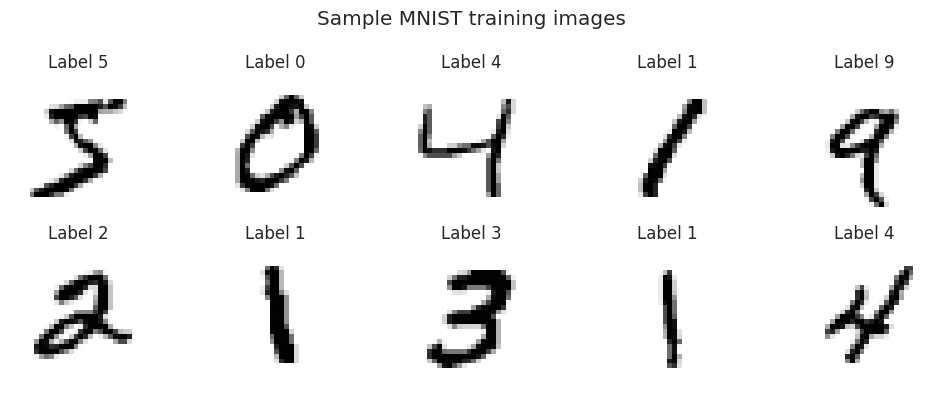

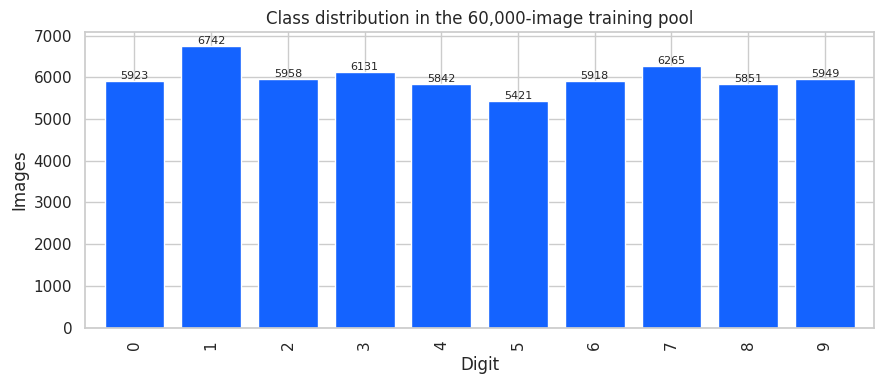

,count
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


In [19]:
(x_pool_raw, y_pool), (x_test_raw, y_test) = keras.datasets.mnist.load_data()
print("Original training pool:", x_pool_raw.shape, y_pool.shape)
print("Held-out test set:", x_test_raw.shape, y_test.shape)
assert x_pool_raw.shape == (60_000, 28, 28)
assert x_test_raw.shape == (10_000, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.flat, x_pool_raw[:10], y_pool[:10]):
    axis.imshow(image, cmap="gray_r")
    axis.set_title(f"Label {label}")
    axis.axis("off")
fig.suptitle("Sample MNIST training images")
fig.tight_layout()
fig.savefig(PLOT_DIR / "sample_digits.png", dpi=160, bbox_inches="tight")
plt.show()

class_counts = pd.Series(y_pool).value_counts().sort_index()
ax = class_counts.plot.bar(figsize=(9, 4), color="#1463ff", width=0.78)
ax.set(title="Class distribution in the 60,000-image training pool", xlabel="Digit", ylabel="Images")
ax.bar_label(ax.containers[0], fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "class_distribution.png", dpi=160, bbox_inches="tight")
plt.show()
display(class_counts.rename("count").to_frame())


In [20]:
x_train_raw, x_val_raw, y_train_all, y_val_all = train_test_split(
    x_pool_raw,
    y_pool,
    test_size=5_000,
    random_state=SEED,
    stratify=y_pool,
)
assert len(x_train_raw) == 55_000 and len(x_val_raw) == 5_000

x_train_fc_all = x_train_raw.astype("float32").reshape(-1, 784) / 255.0
x_val_fc_all = x_val_raw.astype("float32").reshape(-1, 784) / 255.0
x_test_fc = x_test_raw.astype("float32").reshape(-1, 784) / 255.0

x_train_cnn_all = x_train_raw.astype("float32")[..., None] / 255.0
x_val_cnn_all = x_val_raw.astype("float32")[..., None] / 255.0
x_test_cnn = x_test_raw.astype("float32")[..., None] / 255.0

if RUN_FULL:
    x_train_fc, y_train = x_train_fc_all, y_train_all
    x_val_fc, y_val = x_val_fc_all, y_val_all
    x_train_cnn, x_val_cnn = x_train_cnn_all, x_val_cnn_all
    EXPERIMENT_EPOCHS, FINAL_EPOCHS = 10, 18
else:
    x_train_fc, y_train = x_train_fc_all[:12_000], y_train_all[:12_000]
    x_val_fc, y_val = x_val_fc_all[:2_000], y_val_all[:2_000]
    x_train_cnn, x_val_cnn = x_train_cnn_all[:12_000], x_val_cnn_all[:2_000]
    EXPERIMENT_EPOCHS, FINAL_EPOCHS = 2, 3

print("Official split:", len(x_train_raw), len(x_val_raw), len(x_test_raw))
print("Run subset:", len(x_train_fc), len(x_val_fc))
print("FC shapes:", x_train_fc_all.shape, x_val_fc_all.shape, x_test_fc.shape)
print("CNN shapes:", x_train_cnn_all.shape, x_val_cnn_all.shape, x_test_cnn.shape)
print("Scaled range:", float(x_train_fc_all.min()), float(x_train_fc_all.max()))


Official split: 55000 5000 10000
Run subset: 55000 5000
FC shapes: (55000, 784) (5000, 784) (10000, 784)
CNN shapes: (55000, 28, 28, 1) (5000, 28, 28, 1) (10000, 28, 28, 1)
Scaled range: 0.0 1.0


## Experiment record

Every run contributes one row to the same table. The four questions below guide
the written analysis after each experiment.

1. What did I change?
2. What happened?
3. Why did it happen?
4. What did I learn?


In [21]:
records = []
histories = {}
models = {}

def execute(config, callbacks=()):
    model, history, record = run_experiment(
        config,
        x_train_fc,
        y_train,
        x_val_fc,
        y_val,
        callbacks=callbacks,
    )
    records.append(record)
    histories[config.name] = history
    models[config.name] = model
    return model, history, record

def phase_table(phase):
    columns = [
        "name", "hidden_units", "parameters", "activation", "initializer",
        "optimizer", "learning_rate", "batch_size", "dropout", "l2",
        "training_seconds", "best_val_accuracy", "generalization_gap"
    ]
    return pd.DataFrame(records).query("phase == @phase")[columns].sort_values(
        "best_val_accuracy", ascending=False
    )

def plot_histories(names, metric="accuracy", title=None, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name in names:
        frame = histories[name]
        axes[0].plot(frame[metric], label=name)
        axes[1].plot(frame[f"val_{metric}"], label=name)
    axes[0].set(title=f"Training {metric}", xlabel="Epoch", ylabel=metric)
    axes[1].set(title=f"Validation {metric}", xlabel="Epoch", ylabel=metric)
    axes[1].legend(fontsize=8)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    if filename:
        fig.savefig(PLOT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


## 2. My fully connected architectures

The variants cover one to five hidden layers. `shallow_wide` and `deep_narrow`
have similar parameter counts, which makes their depth versus width comparison
more meaningful than comparing arbitrarily sized networks.


Model: "one_hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 203,522 (795.01 KB)

 Trainable params: 203,522 (795.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
430/430 - 4s - 9ms/step - accuracy: 0.9039 - loss: 0.3295 - val_accuracy: 0.9546 - val_loss: 0.1509
Epoch 2/10
430/430 - 3s - 8ms/step - accuracy: 0.9643 - loss: 0.1204 - val_accuracy: 0.9646 - val_loss: 0.1195
Epoch 3/10
430/430 - 2s - 6ms/step - accuracy: 0.9763 - loss: 0.0800 - val_accuracy: 0.9642 - val_loss: 0.1214
Epoch 4/10
430/430 - 3s - 6ms/step - accuracy: 0.9825 - loss: 0.0586 - val_accuracy: 0.9598 - val_loss: 0.1386
Epoch 5/10
430/430 - 3s - 6ms/step - accuracy: 0.9863 - loss: 0.0440 - val_accuracy: 0.9636 - val_loss: 0.1382
Epoch 6/10
430/430 - 3s - 6ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9644 - val_loss: 0.1457
Epoch 7/10
430/430 - 5s - 12ms/step - accuracy: 0.9911 - loss: 0.0291 - val_accuracy: 0.9712 - val_loss: 0.1204
Epoch 8/10
430/430 - 3s - 6ms/step - accuracy: 0.9922 - loss: 0.0249 - val_accuracy: 0.9656 - val_loss: 0.1460
Epoch 9/10
430/430 - 2s - 6ms/step - accuracy: 0.9925 - loss: 0.0232 - val_accuracy: 0.9728 - val_loss: 0.1254


,name,hidden_units,parameters,activation,initializer,optimizer,learning_rate,batch_size,dropout,l2,training_seconds,best_val_accuracy,generalization_gap
0,one_hidden,256,203530,relu,he_normal,adam,0.001,128,0.0,0.0,47.227,0.9804,0.017018
3,four_hidden,256-128-64-32,244522,relu,he_normal,adam,0.001,128,0.0,0.0,31.555,0.9794,0.016036
2,three_hidden,256-128-64,242762,relu,he_normal,adam,0.001,128,0.0,0.0,28.572,0.9768,0.018527
1,two_hidden,256-128,235146,relu,he_normal,adam,0.001,128,0.0,0.0,24.696,0.9766,0.020964
4,five_hidden,256-128-64-32-16,244890,relu,he_normal,adam,0.001,128,0.0,0.0,33.539,0.9758,0.017418
5,deep_narrow,224-96-48-24,203522,relu,he_normal,adam,0.001,128,0.0,0.0,31.554,0.9746,0.019818


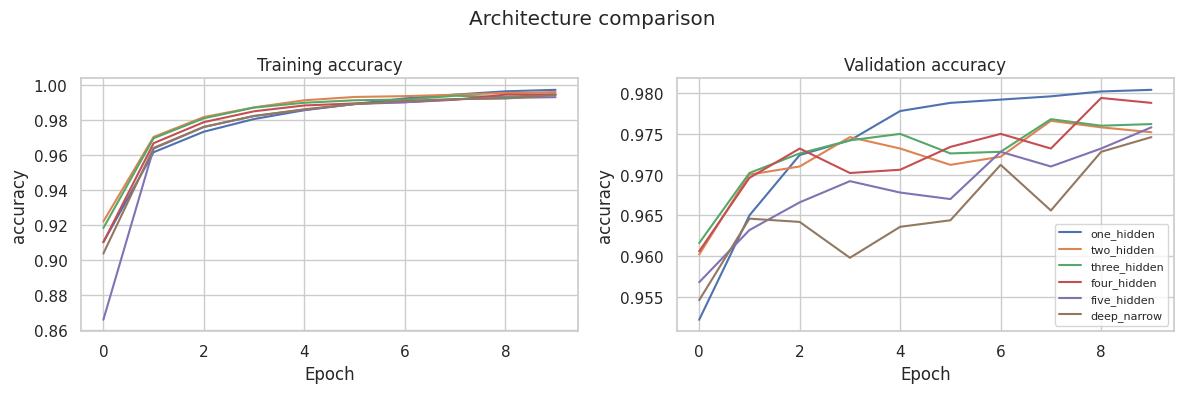

Validation-selected architecture: one_hidden (256,)


In [22]:
architecture_specs = {
    "one_hidden": (256,),
    "two_hidden": (256, 128),
    "three_hidden": (256, 128, 64),
    "four_hidden": (256, 128, 64, 32),
    "five_hidden": (256, 128, 64, 32, 16),
    "deep_narrow": (224, 96, 48, 24),
}
architecture_configs = [
    ExperimentConfig(
        name=name,
        phase="architecture",
        hidden_units=units,
        epochs=EXPERIMENT_EPOCHS,
    )
    for name, units in architecture_specs.items()
]
for config in architecture_configs:
    execute(config)

arch_results = phase_table("architecture")
display(arch_results)
plot_histories(
    [config.name for config in architecture_configs],
    title="Architecture comparison",
    filename="architecture_accuracy.png",
)
best_arch_name = arch_results.iloc[0]["name"]
best_units = architecture_specs[best_arch_name]
print("Validation-selected architecture:", best_arch_name, best_units)


### Architecture analysis

`[WRITE AFTER RUN]` Compare the one-layer network with the deepest network and
compare `one_hidden` with `deep_narrow`. Quote their parameter counts, training
times, validation accuracies, and generalization gaps. Explain whether added
depth improved the representation or mainly added optimization difficulty.


## 3. Activation functions and gradients

The activation comparison holds architecture, initialization, optimizer,
learning rate, batch size, and epochs fixed. The separate six-layer sigmoid
network records kernel-gradient norms at the end of every epoch.


Model: "activation_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
430/430 - 3s - 7ms/step - accuracy: 0.8667 - loss: 0.5263 - val_accuracy: 0.9120 - val_loss: 0.3093
Epoch 2/10
430/430 - 2s - 5ms/step - accuracy: 0.9248 - loss: 0.2633 - val_accuracy: 0.9312 - val_loss: 0.2434
Epoch 3/10
430/430 - 2s - 5ms/step - accuracy: 0.9393 - loss: 0.2103 - val_accuracy: 0.9448 - val_loss: 0.2025
Epoch 4/10
430/430 - 2s - 5ms/step - accuracy: 0.9501 - loss: 0.1738 - val_accuracy: 0.9512 - val_loss: 0.1738
Epoch 5/10
430/430 - 3s - 6ms/step - accuracy: 0.9580 - loss: 0.1465 - val_accuracy: 0.9570 - val_loss: 0.1529
Epoch 6/10
430/430 - 2s - 5ms/step - accuracy: 0.9643 - loss: 0.1253 - val_accuracy: 0.9618 - val_loss: 0.1370
Epoch 7/10
430/430 - 2s - 5ms/step - accuracy: 0.9695 - loss: 0.1082 - val_accuracy: 0.9636 - val_loss: 0.1245
Epoch 8/10
430/430 - 2s - 5ms/step - accuracy: 0.9736 - loss: 0.0940 - val_accuracy: 0.9670 - val_loss: 0.1144
Epoch 9/10
430/430 - 2s - 4ms/step - accuracy: 0.9772 - loss: 0.0822 - val_accuracy: 0.9688 - val_loss: 0.1062
E

,name,hidden_units,parameters,activation,initializer,optimizer,learning_rate,batch_size,dropout,l2,training_seconds,best_val_accuracy,generalization_gap
6,activation_relu,256,203530,relu,he_normal,adam,0.001,128,0.0,0.0,23.813,0.9804,0.017018
7,activation_tanh,256,203530,tanh,glorot_uniform,adam,0.001,128,0.0,0.0,25.772,0.9782,0.016164
8,activation_sigmoid,256,203530,sigmoid,glorot_uniform,adam,0.001,128,0.0,0.0,22.525,0.9698,0.010418


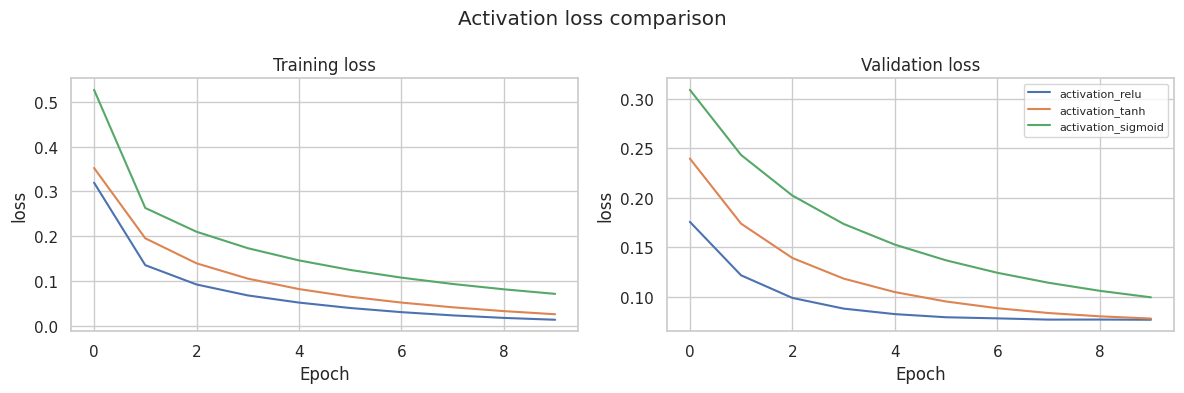

Validation-selected activation: relu


In [23]:
activation_configs = [
    ExperimentConfig(
        name=f"activation_{activation}",
        phase="activation",
        hidden_units=best_units,
        activation=activation,
        initializer="he_normal" if activation == "relu" else "glorot_uniform",
        epochs=EXPERIMENT_EPOCHS,
    )
    for activation in ("relu", "tanh", "sigmoid")
]
for config in activation_configs:
    execute(config)

activation_results = phase_table("activation")
display(activation_results)
plot_histories(
    [config.name for config in activation_configs],
    metric="loss",
    title="Activation loss comparison",
    filename="activation_loss.png",
)
best_activation = activation_results.iloc[0]["activation"]
print("Validation-selected activation:", best_activation)


Model: "deep_sigmoid_gradient_test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_6 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,330 (720.04 KB)

 Trainable params: 184,330 (720.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
430/430 - 5s - 12ms/step - accuracy: 0.3333 - loss: 1.5958 - val_accuracy: 0.5504 - val_loss: 1.1068
Epoch 2/10
430/430 - 3s - 7ms/step - accuracy: 0.7068 - loss: 0.8079 - val_accuracy: 0.8436 - val_loss: 0.5689
Epoch 3/10
430/430 - 3s - 7ms/step - accuracy: 0.8789 - loss: 0.4389 - val_accuracy: 0.8964 - val_loss: 0.3930
Epoch 4/10
430/430 - 4s - 8ms/step - accuracy: 0.9120 - loss: 0.3157 - val_accuracy: 0.9138 - val_loss: 0.3157
Epoch 5/10
430/430 - 3s - 7ms/step - accuracy: 0.9284 - loss: 0.2530 - val_accuracy: 0.9258 - val_loss: 0.2795
Epoch 6/10
430/430 - 3s - 7ms/step - accuracy: 0.9397 - loss: 0.2154 - val_accuracy: 0.9256 - val_loss: 0.2634
Epoch 7/10
430/430 - 3s - 7ms/step - accuracy: 0.9444 - loss: 0.1982 - val_accuracy: 0.8946 - val_loss: 0.3446
Epoch 8/10
430/430 - 4s - 9ms/step - accuracy: 0.9492 - loss: 0.1815 - val_accuracy: 0.9348 - val_loss: 0.2266
Epoch 9/10
430/430 - 4s - 10ms/step - accuracy: 0.9567 - loss: 0.1594 - val_accuracy: 0.9412 - val_loss: 0.2077

,epoch,layer,gradient_norm
0,1,hidden_1,0.105084
1,1,hidden_2,0.085956
2,1,hidden_3,0.064702
3,1,hidden_4,0.039444
4,1,hidden_5,0.028811


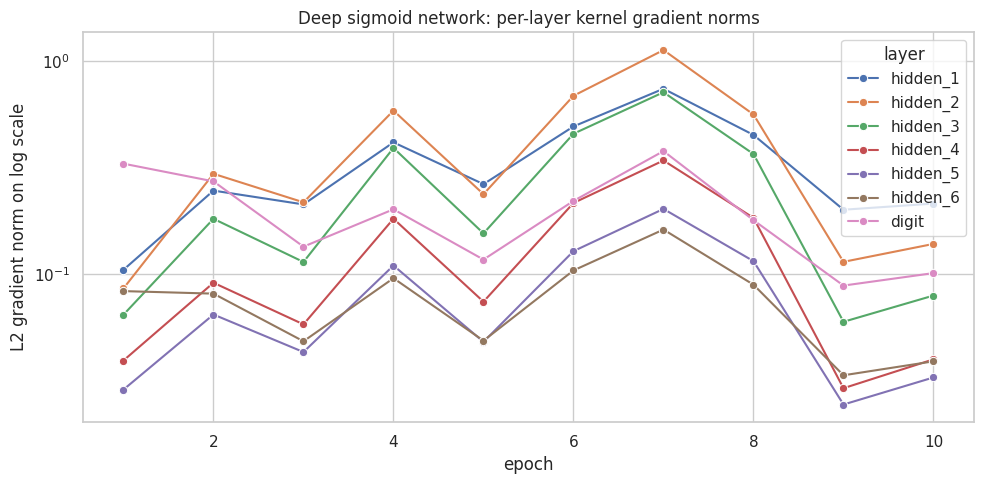

In [24]:
gradient_logger = GradientNormLogger(x_train_fc[:256], y_train[:256])
deep_sigmoid = ExperimentConfig(
    name="deep_sigmoid_gradient_test",
    phase="gradient_diagnostic",
    hidden_units=(128, 128, 128, 128, 128, 128),
    activation="sigmoid",
    initializer="glorot_uniform",
    epochs=EXPERIMENT_EPOCHS,
)
execute(deep_sigmoid, callbacks=[gradient_logger])
gradient_frame = gradient_logger.to_frame()
gradient_frame.to_csv(ARTIFACT_DIR / "gradient_norms.csv", index=False)
display(gradient_frame.head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=gradient_frame, x="epoch", y="gradient_norm", hue="layer", marker="o")
plt.yscale("log")
plt.title("Deep sigmoid network: per-layer kernel gradient norms")
plt.ylabel("L2 gradient norm on log scale")
plt.tight_layout()
plt.savefig(PLOT_DIR / "sigmoid_gradient_norms.png", dpi=160, bbox_inches="tight")
plt.show()


### Activation and gradient analysis

`[WRITE AFTER RUN]` State which activation converged fastest and quote the final
validation losses. Use the gradient-norm plot to compare the first and last
hidden layers. Sigmoid derivatives are small in saturated regions; multiplying
many such derivatives can shrink the signal sent to early layers. ReLU keeps a
unit derivative for positive inputs, though inactive units can still receive a
zero derivative. Exploding gradients are the opposite failure: repeated large
derivatives make updates unstable or non-finite.


## 4. Weight initialization


Model: "initializer_zeros"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
430/430 - 4s - 9ms/step - accuracy: 0.9104 - loss: 0.3196 - val_accuracy: 0.9522 - val_loss: 0.1759
Epoch 2/10
430/430 - 2s - 5ms/step - accuracy: 0.9618 - loss: 0.1360 - val_accuracy: 0.9650 - val_loss: 0.1219
Epoch 3/10
430/430 - 2s - 5ms/step - accuracy: 0.9735 - loss: 0.0929 - val_accuracy: 0.9724 - val_loss: 0.0990
Epoch 4/10
430/430 - 2s - 5ms/step - accuracy: 0.9807 - loss: 0.0686 - val_accuracy: 0.9742 - val_loss: 0.0882
Epoch 5/10
430/430 - 2s - 5ms/step - accuracy: 0.9858 - loss: 0.0526 - val_accuracy: 0.9778 - val_loss: 0.0827
Epoch 6/10
430/430 - 2s - 5ms/step - accuracy: 0.9893 - loss: 0.0405 - val_accuracy: 0.9788 - val_loss: 0.0795
Epoch 7/10
430/430 - 3s - 7ms/step - accuracy: 0.9925 - loss: 0.0313 - val_accuracy: 0.9792 - val_loss: 0.0784
Epoch 8/10
430/430 - 2s - 5ms/step - accuracy: 0.9947 - loss: 0.0241 - val_accuracy: 0.9796 - val_loss: 0.0771
Epoch 9/10
430/430 - 2s - 5ms/step - accuracy: 0.9966 - loss: 0.0185 - val_accuracy: 0.9802 - val_loss: 0.0772
E

,name,hidden_units,parameters,activation,initializer,optimizer,learning_rate,batch_size,dropout,l2,training_seconds,best_val_accuracy,generalization_gap
12,initializer_he_normal,256,203530,relu,he_normal,adam,0.001,128,0.0,0.0,24.032,0.9804,0.017018
11,initializer_glorot_uniform,256,203530,relu,glorot_uniform,adam,0.001,128,0.0,0.0,25.695,0.9776,0.020473
10,initializer_zeros,256,203530,relu,zeros,adam,0.001,128,0.0,0.0,23.531,0.1124,-0.000036


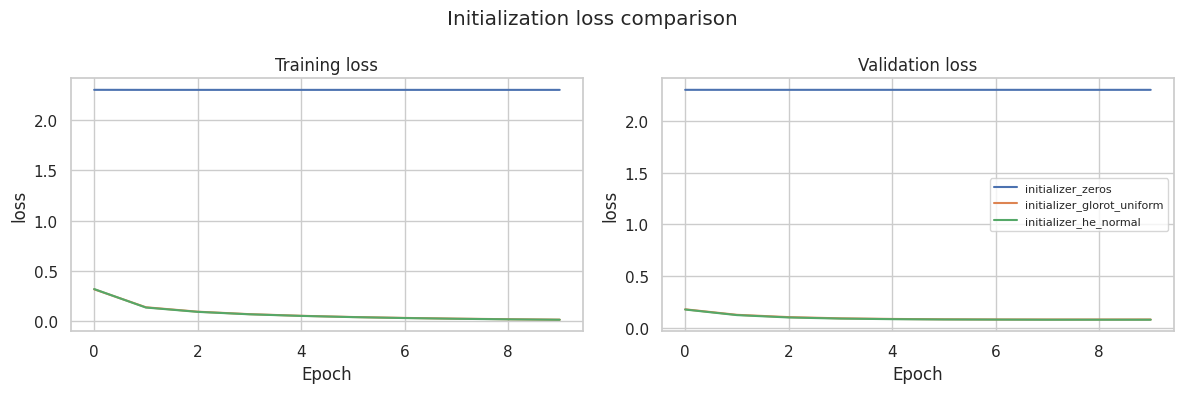

Validation-selected non-zero initializer: he_normal


In [25]:
initializers = ("zeros", "glorot_uniform", "he_normal")
initialization_configs = [
    ExperimentConfig(
        name=f"initializer_{initializer}",
        phase="initialization",
        hidden_units=best_units,
        activation=best_activation,
        initializer=initializer,
        epochs=EXPERIMENT_EPOCHS,
    )
    for initializer in initializers
]
for config in initialization_configs:
    execute(config)

initialization_results = phase_table("initialization")
display(initialization_results)
plot_histories(
    [config.name for config in initialization_configs],
    metric="loss",
    title="Initialization loss comparison",
    filename="initialization_loss.png",
)
eligible_initializers = initialization_results.query("initializer != 'zeros'")
best_initializer = eligible_initializers.iloc[0]["initializer"]
print("Validation-selected non-zero initializer:", best_initializer)


### Initialization analysis

`[WRITE AFTER RUN]` Quote the zero, Glorot, and He results. All-zero weights make
neurons in the same layer start identically and receive identical updates. The
network cannot break that symmetry, so increasing the number of hidden neurons
does not create distinct learned features. Relate the winning initializer to
the selected activation and its intended variance scaling.


## 5. Optimization, learning rate, and batch size


Model: "optimizer_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
108/108 - 2s - 17ms/step - accuracy: 0.8601 - loss: 0.5101 - val_accuracy: 0.9240 - val_loss: 0.2689
Epoch 2/10
108/108 - 1s - 6ms/step - accuracy: 0.9398 - loss: 0.2155 - val_accuracy: 0.9480 - val_loss: 0.1926
Epoch 3/10
108/108 - 1s - 6ms/step - accuracy: 0.9561 - loss: 0.1582 - val_accuracy: 0.9596 - val_loss: 0.1536
Epoch 4/10
108/108 - 1s - 11ms/step - accuracy: 0.9657 - loss: 0.1243 - val_accuracy: 0.9646 - val_loss: 0.1305
Epoch 5/10
108/108 - 1s - 6ms/step - accuracy: 0.9720 - loss: 0.1017 - val_accuracy: 0.9672 - val_loss: 0.1154
Epoch 6/10
108/108 - 1s - 6ms/step - accuracy: 0.9771 - loss: 0.0855 - val_accuracy: 0.9692 - val_loss: 0.1048
Epoch 7/10
108/108 - 1s - 6ms/step - accuracy: 0.9807 - loss: 0.0730 - val_accuracy: 0.9714 - val_loss: 0.0973
Epoch 8/10
108/108 - 1s - 6ms/step - accuracy: 0.9833 - loss: 0.0631 - val_accuracy: 0.9728 - val_loss: 0.0915
Epoch 9/10
108/108 - 1s - 6ms/step - accuracy: 0.9858 - loss: 0.0551 - val_accuracy: 0.9740 - val_loss: 0.0868

,name,hidden_units,parameters,activation,initializer,optimizer,learning_rate,batch_size,dropout,l2,training_seconds,best_val_accuracy,generalization_gap
20,batch_128,256,203530,relu,he_normal,adam,0.001,128,0.0,0.0,23.288,0.9804,0.017018
19,batch_32,256,203530,relu,he_normal,adam,0.001,32,0.0,0.0,84.558,0.9774,0.022364
21,batch_512,256,203530,relu,he_normal,adam,0.001,512,0.0,0.0,8.628,0.9740,0.014036


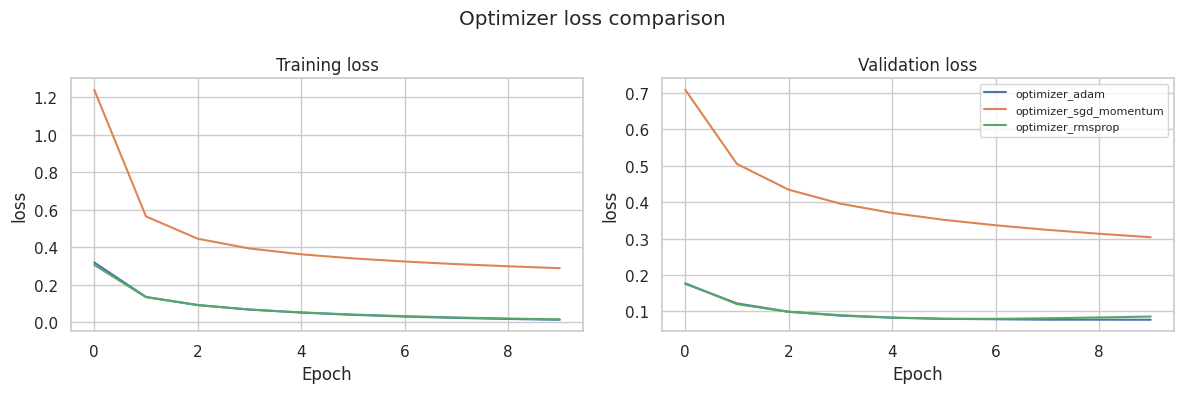

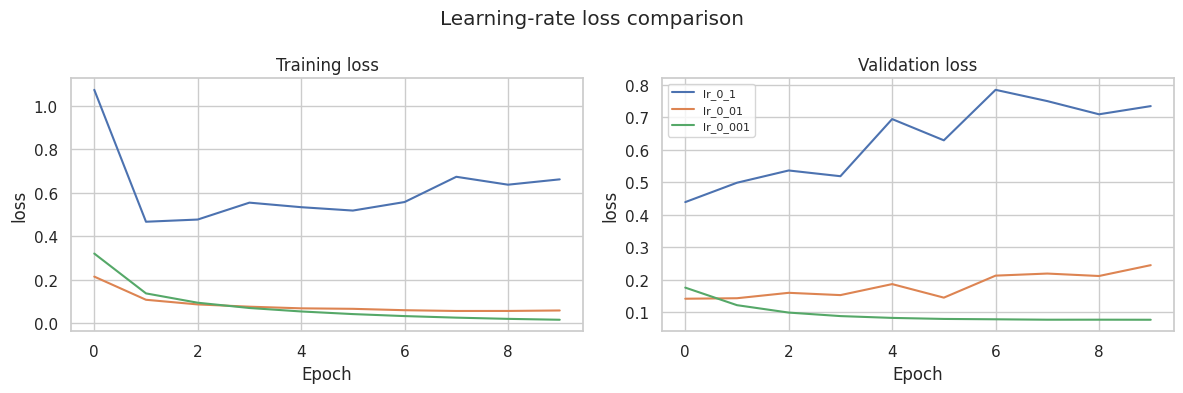

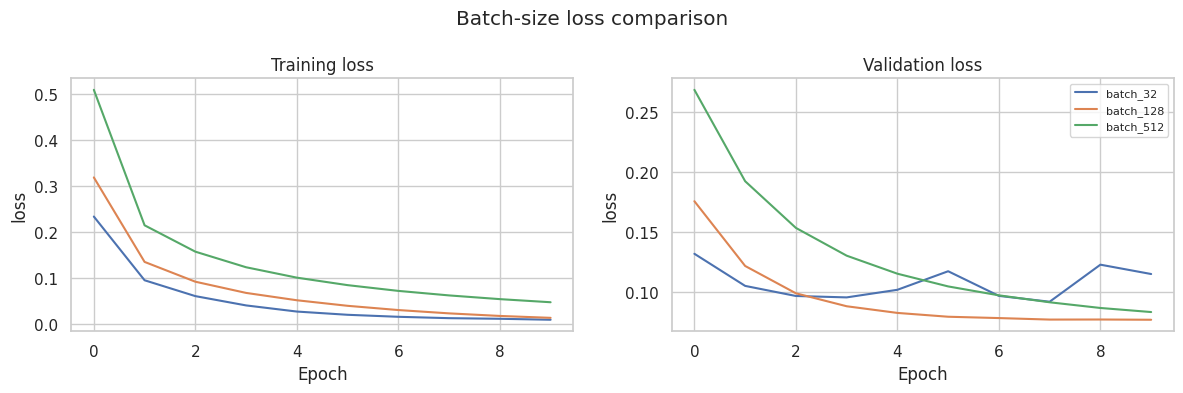

Selected: adam 0.001 128


In [26]:
optimizer_configs = [
    ExperimentConfig(
        name=f"optimizer_{optimizer}",
        phase="optimizer",
        hidden_units=best_units,
        activation=best_activation,
        initializer=best_initializer,
        optimizer=optimizer,
        learning_rate=0.001,
        epochs=EXPERIMENT_EPOCHS,
    )
    for optimizer in ("adam", "sgd_momentum", "rmsprop")
]
for config in optimizer_configs:
    execute(config)
optimizer_results = phase_table("optimizer")
display(optimizer_results)
best_optimizer = optimizer_results.iloc[0]["optimizer"]

learning_rate_configs = [
    ExperimentConfig(
        name=f"lr_{str(rate).replace('.', '_')}",
        phase="learning_rate",
        hidden_units=best_units,
        activation=best_activation,
        initializer=best_initializer,
        optimizer=best_optimizer,
        learning_rate=rate,
        epochs=EXPERIMENT_EPOCHS,
    )
    for rate in (0.1, 0.01, 0.001)
]
for config in learning_rate_configs:
    execute(config)
learning_rate_results = phase_table("learning_rate")
display(learning_rate_results)
best_learning_rate = float(learning_rate_results.iloc[0]["learning_rate"])

batch_configs = [
    ExperimentConfig(
        name=f"batch_{batch_size}",
        phase="batch_size",
        hidden_units=best_units,
        activation=best_activation,
        initializer=best_initializer,
        optimizer=best_optimizer,
        learning_rate=best_learning_rate,
        batch_size=batch_size,
        epochs=EXPERIMENT_EPOCHS,
    )
    for batch_size in (32, 128, 512)
]
for config in batch_configs:
    execute(config)
batch_results = phase_table("batch_size")
display(batch_results)
best_batch_size = int(batch_results.iloc[0]["batch_size"])

plot_histories(
    [config.name for config in optimizer_configs],
    metric="loss",
    title="Optimizer loss comparison",
    filename="optimizer_loss.png",
)
plot_histories(
    [config.name for config in learning_rate_configs],
    metric="loss",
    title="Learning-rate loss comparison",
    filename="learning_rate_loss.png",
)
plot_histories(
    [config.name for config in batch_configs],
    metric="loss",
    title="Batch-size loss comparison",
    filename="batch_size_loss.png",
)
print("Selected:", best_optimizer, best_learning_rate, best_batch_size)


### Optimization analysis

`[WRITE AFTER RUN]` Compare convergence in the first few epochs and the best
validation result for all three optimizers. Explain any instability at learning
rate 0.1 using the observed loss, not a generic claim. Compare batch sizes using
both training time and validation accuracy. Smaller batches produce noisier,
more frequent updates; larger batches make fewer updates per epoch.


## 6. Regularization


Model: "no_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
430/430 - 3s - 8ms/step - accuracy: 0.9020 - loss: 0.3838 - val_accuracy: 0.9506 - val_loss: 0.2189
Epoch 2/10
430/430 - 3s - 7ms/step - accuracy: 0.9554 - loss: 0.1946 - val_accuracy: 0.9634 - val_loss: 0.1689
Epoch 3/10
430/430 - 2s - 5ms/step - accuracy: 0.9660 - loss: 0.1549 - val_accuracy: 0.9712 - val_loss: 0.1447
Epoch 4/10
430/430 - 2s - 5ms/step - accuracy: 0.9734 - loss: 0.1312 - val_accuracy: 0.9754 - val_loss: 0.1341
Epoch 5/10
430/430 - 2s - 5ms/step - accuracy: 0.9767 - loss: 0.1181 - val_accuracy: 0.9762 - val_loss: 0.1265
Epoch 6/10
430/430 - 2s - 5ms/step - accuracy: 0.9795 - loss: 0.1069 - val_accuracy: 0.9766 - val_loss: 0.1242
Epoch 7/10
430/430 - 2s - 6ms/step - accuracy: 0.9819 - loss: 0.0997 - val_accuracy: 0.9784 - val_loss: 0.1175
Epoch 8/10
430/430 - 3s - 6ms/step - accuracy: 0.9837 - loss: 0.0945 - val_accuracy: 0.9786 - val_loss: 0.1127
Epoch 9/10
430/430 - 2s - 5ms/step - accuracy: 0.9848 - loss: 0.0890 - val_accuracy: 0.9784 - val_loss: 0.1121
E

,name,hidden_units,parameters,activation,initializer,optimizer,learning_rate,batch_size,dropout,l2,training_seconds,best_val_accuracy,generalization_gap
22,no_regularization,256,203530,relu,he_normal,adam,0.001,128,0.0,0.0000,22.952,0.9804,0.017018
23,dropout_020,256,203530,relu,he_normal,adam,0.001,128,0.2,0.0000,24.111,0.9798,0.011455
24,l2_0001,256,203530,relu,he_normal,adam,0.001,128,0.0,0.0001,23.909,0.9796,0.014291
25,dropout_l2,256,203530,relu,he_normal,adam,0.001,128,0.2,0.0001,25.201,0.9786,0.007873


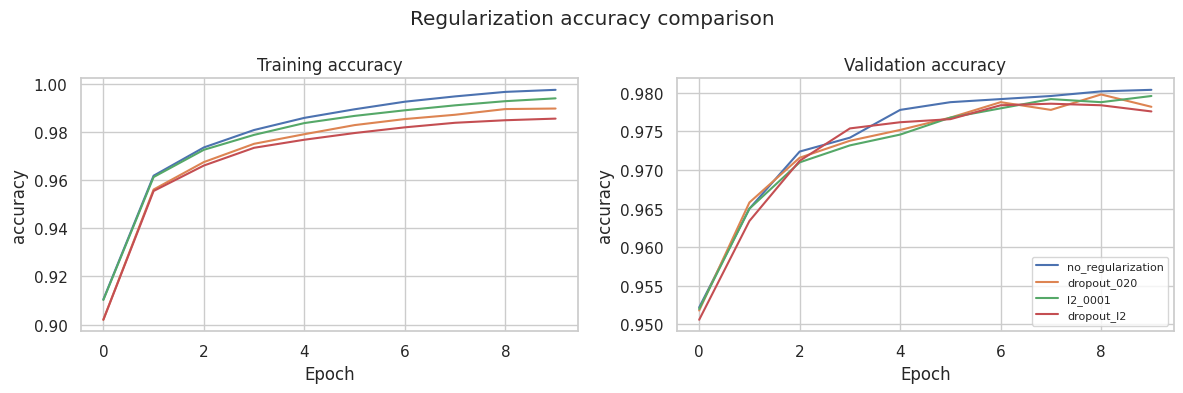

Validation-selected final configuration: ExperimentConfig(name='no_regularization', phase='regularization', hidden_units=(256,), activation='relu', initializer='he_normal', optimizer='adam', learning_rate=0.001, batch_size=128, epochs=10, dropout=0.0, l2=0.0)


In [27]:
regularization_specs = [
    ("no_regularization", 0.0, 0.0),
    ("dropout_020", 0.20, 0.0),
    ("l2_0001", 0.0, 1e-4),
    ("dropout_l2", 0.20, 1e-4),
]
regularization_configs = [
    ExperimentConfig(
        name=name,
        phase="regularization",
        hidden_units=best_units,
        activation=best_activation,
        initializer=best_initializer,
        optimizer=best_optimizer,
        learning_rate=best_learning_rate,
        batch_size=best_batch_size,
        epochs=EXPERIMENT_EPOCHS,
        dropout=dropout,
        l2=l2,
    )
    for name, dropout, l2 in regularization_specs
]
for config in regularization_configs:
    execute(config)

regularization_results = phase_table("regularization")
display(regularization_results)
plot_histories(
    [config.name for config in regularization_configs],
    title="Regularization accuracy comparison",
    filename="regularization_accuracy.png",
)
best_regularization_name = regularization_results.iloc[0]["name"]
selected_config = next(c for c in regularization_configs if c.name == best_regularization_name)
print("Validation-selected final configuration:", selected_config)


### Regularization analysis

`[WRITE AFTER RUN]` Compare the training-validation gap with and without
regularization. State whether the unregularized model overfit enough for dropout
or L2 to help. MNIST is clean, balanced, and large relative to these networks,
so a well-sized model may show only a small gap. Strong dropout can then reduce
both training and validation performance.


## 7. Final fully connected model

The choices above are now frozen. The next cell trains once with early stopping,
evaluates the untouched test set, saves the model, reloads it, and verifies that
the restored predictions match.


Model: "final_fully_connected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18
430/430 - 3s - 7ms/step - accuracy: 0.9104 - loss: 0.3196 - val_accuracy: 0.9522 - val_loss: 0.1759
Epoch 2/18
430/430 - 3s - 6ms/step - accuracy: 0.9618 - loss: 0.1360 - val_accuracy: 0.9650 - val_loss: 0.1219
Epoch 3/18
430/430 - 2s - 5ms/step - accuracy: 0.9735 - loss: 0.0929 - val_accuracy: 0.9724 - val_loss: 0.0990
Epoch 4/18
430/430 - 2s - 5ms/step - accuracy: 0.9807 - loss: 0.0686 - val_accuracy: 0.9742 - val_loss: 0.0882
Epoch 5/18
430/430 - 2s - 5ms/step - accuracy: 0.9858 - loss: 0.0526 - val_accuracy: 0.9778 - val_loss: 0.0827
Epoch 6/18
430/430 - 2s - 5ms/step - accuracy: 0.9893 - loss: 0.0405 - val_accuracy: 0.9788 - val_loss: 0.0795
Epoch 7/18
430/430 - 2s - 5ms/step - accuracy: 0.9925 - loss: 0.0313 - val_accuracy: 0.9792 - val_loss: 0.0784
Epoch 8/18
430/430 - 3s - 7ms/step - accuracy: 0.9947 - loss: 0.0241 - val_accuracy: 0.9796 - val_loss: 0.0771
Epoch 9/18
430/430 - 2s - 5ms/step - accuracy: 0.9966 - loss: 0.0185 - val_accuracy: 0.9802 - val_loss: 0.0772
E

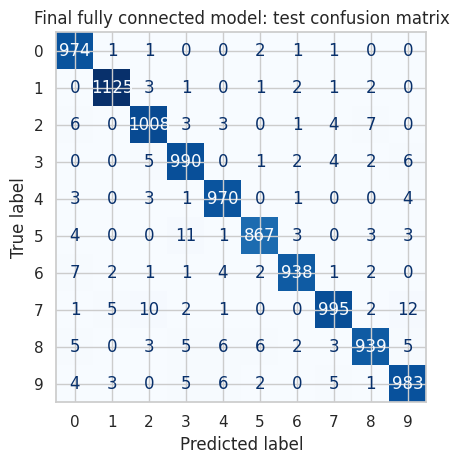

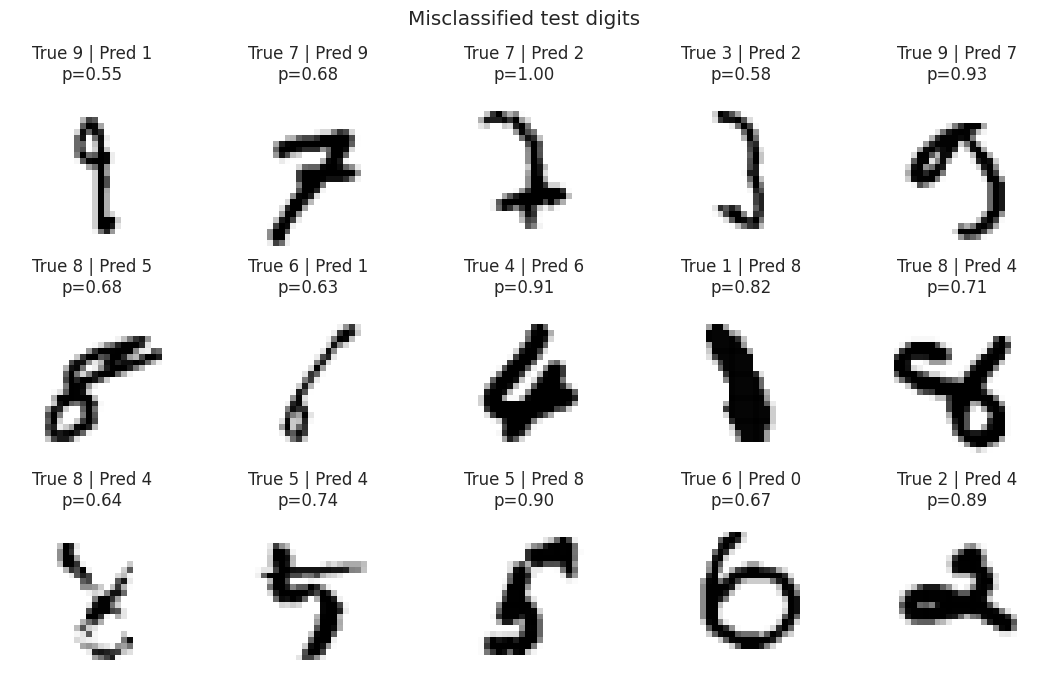

In [28]:
final_config = ExperimentConfig(
    name="final_fully_connected",
    phase="final_fc",
    hidden_units=selected_config.hidden_units,
    activation=selected_config.activation,
    initializer=selected_config.initializer,
    optimizer=selected_config.optimizer,
    learning_rate=selected_config.learning_rate,
    batch_size=selected_config.batch_size,
    epochs=FINAL_EPOCHS,
    dropout=selected_config.dropout,
    l2=selected_config.l2,
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
final_fc, final_history, final_record = run_experiment(
    final_config,
    x_train_fc_all if RUN_FULL else x_train_fc,
    y_train_all if RUN_FULL else y_train,
    x_val_fc_all if RUN_FULL else x_val_fc,
    y_val_all if RUN_FULL else y_val,
    callbacks=[early_stopping],
)
records.append(final_record)
histories[final_config.name] = final_history

fc_test_loss, fc_test_accuracy = final_fc.evaluate(x_test_fc, y_test, verbose=0)
fc_probabilities = final_fc.predict(x_test_fc, verbose=0)
fc_predictions = fc_probabilities.argmax(axis=1)
fc_confusion = confusion_matrix(y_test, fc_predictions)
print(f"FC test loss: {fc_test_loss:.4f}")
print(f"FC test accuracy: {fc_test_accuracy:.4f}")
print(classification_report(y_test, fc_predictions, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test, fc_predictions, cmap="Blues", colorbar=False, values_format="d"
)
plt.title("Final fully connected model: test confusion matrix")
plt.tight_layout()
plt.savefig(PLOT_DIR / "fc_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

error_indices = np.flatnonzero(fc_predictions != y_test)
pd.DataFrame({
    "test_index": error_indices,
    "true_label": y_test[error_indices],
    "predicted_label": fc_predictions[error_indices],
    "predicted_probability": fc_probabilities[
        error_indices, fc_predictions[error_indices]
    ],
}).to_csv(ARTIFACT_DIR / "fc_misclassifications.csv", index=False)
pd.DataFrame(fc_confusion).to_csv(ARTIFACT_DIR / "fc_confusion_matrix.csv", index=False)
rng = np.random.default_rng(SEED)
shown = rng.choice(error_indices, size=min(15, len(error_indices)), replace=False)
fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for axis in axes.flat:
    axis.axis("off")
for axis, index in zip(axes.flat, shown):
    axis.imshow(x_test_raw[index], cmap="gray_r")
    axis.set_title(
        f"True {y_test[index]} | Pred {fc_predictions[index]}\n"
        f"p={fc_probabilities[index, fc_predictions[index]]:.2f}"
    )
    axis.axis("off")
fig.suptitle("Misclassified test digits")
fig.tight_layout()
fig.savefig(PLOT_DIR / "fc_misclassifications.png", dpi=160, bbox_inches="tight")
plt.show()


In [29]:
model_path = ARTIFACT_DIR / "final_fc.keras"
final_fc.save(model_path)
restored_fc = keras.models.load_model(model_path)
before = final_fc.predict(x_test_fc[:32], verbose=0)
after = restored_fc.predict(x_test_fc[:32], verbose=0)
np.testing.assert_allclose(before, after, rtol=1e-5, atol=1e-6)
print("Restored predictions match the original model.")

save_metadata(
    ARTIFACT_DIR / "model_metadata.json",
    model="final_fully_connected",
    input_shape=[784],
    classes=list(range(10)),
    scaling="pixel / 255.0",
    seed=SEED,
    test_accuracy=float(fc_test_accuracy),
    test_loss=float(fc_test_loss),
    config={
        "hidden_units": list(final_config.hidden_units),
        "activation": final_config.activation,
        "initializer": final_config.initializer,
        "optimizer": final_config.optimizer,
        "learning_rate": final_config.learning_rate,
        "batch_size": final_config.batch_size,
        "dropout": final_config.dropout,
        "l2": final_config.l2,
    },
)


Restored predictions match the original model.


### Final fully connected model analysis

`[WRITE AFTER RUN]` Report the selected configuration, best validation epoch,
test accuracy, most common confusion pairs, and two visually ambiguous errors.
Explain whether the held-out result agrees with the validation estimate.


## 8. Classical CNN benchmark

The fully connected work is complete. This convolution-pooling-convolution-
pooling stack now receives the image grid and uses the same optimizer, learning
rate, batch size, and maximum epoch budget where reasonable.


Model: "classical_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │       192,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit (Dense)                   │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,230 (996.99 KB)

 Trainable params: 255,230 (996.99 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18
430/430 - 5s - 12ms/step - accuracy: 0.9375 - loss: 0.2084 - val_accuracy: 0.9814 - val_loss: 0.0653
Epoch 2/18
430/430 - 4s - 8ms/step - accuracy: 0.9847 - loss: 0.0506 - val_accuracy: 0.9862 - val_loss: 0.0472
Epoch 3/18
430/430 - 4s - 9ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.9870 - val_loss: 0.0447
Epoch 4/18
430/430 - 5s - 11ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9876 - val_loss: 0.0441
Epoch 5/18
430/430 - 3s - 7ms/step - accuracy: 0.9940 - loss: 0.0195 - val_accuracy: 0.9882 - val_loss: 0.0416
Epoch 6/18
430/430 - 4s - 9ms/step - accuracy: 0.9950 - loss: 0.0166 - val_accuracy: 0.9872 - val_loss: 0.0409
Epoch 7/18
430/430 - 3s - 7ms/step - accuracy: 0.9951 - loss: 0.0139 - val_accuracy: 0.9894 - val_loss: 0.0358
Epoch 8/18
430/430 - 3s - 7ms/step - accuracy: 0.9964 - loss: 0.0118 - val_accuracy: 0.9900 - val_loss: 0.0385
Epoch 9/18
430/430 - 3s - 8ms/step - accuracy: 0.9965 - loss: 0.0101 - val_accuracy: 0.9884 - val_loss: 0.0406

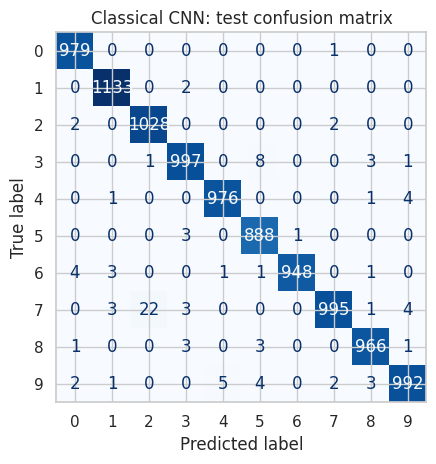

,model,parameters,training_seconds,test_accuracy,test_errors
0,Student-designed fully connected,203530,29.091,0.9789,211
1,Classical CNN benchmark,255230,66.667,0.9902,98


In [30]:
cnn, cnn_history, cnn_record = train_cnn(
    x_train_cnn_all if RUN_FULL else x_train_cnn,
    y_train_all if RUN_FULL else y_train,
    x_val_cnn_all if RUN_FULL else x_val_cnn,
    y_val_all if RUN_FULL else y_val,
    epochs=FINAL_EPOCHS,
    batch_size=final_config.batch_size,
    learning_rate=final_config.learning_rate,
    optimizer_name=final_config.optimizer,
)
records.append(cnn_record)
histories["classical_cnn"] = cnn_history

cnn_test_loss, cnn_test_accuracy = cnn.evaluate(x_test_cnn, y_test, verbose=0)
cnn_probabilities = cnn.predict(x_test_cnn, verbose=0)
cnn_predictions = cnn_probabilities.argmax(axis=1)
cnn_confusion = confusion_matrix(y_test, cnn_predictions)
print(f"CNN test loss: {cnn_test_loss:.4f}")
print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, cnn_predictions, cmap="Blues", colorbar=False, values_format="d"
)
plt.title("Classical CNN: test confusion matrix")
plt.tight_layout()
plt.savefig(PLOT_DIR / "cnn_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

comparison = pd.DataFrame([
    {
        "model": "Student-designed fully connected",
        "parameters": final_fc.count_params(),
        "training_seconds": final_record["training_seconds"],
        "test_accuracy": fc_test_accuracy,
        "test_errors": int((fc_predictions != y_test).sum()),
    },
    {
        "model": "Classical CNN benchmark",
        "parameters": cnn.count_params(),
        "training_seconds": cnn_record["training_seconds"],
        "test_accuracy": cnn_test_accuracy,
        "test_errors": int((cnn_predictions != y_test).sum()),
    },
])
comparison.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)
cnn_error_indices = np.flatnonzero(cnn_predictions != y_test)
pd.DataFrame({
    "test_index": cnn_error_indices,
    "true_label": y_test[cnn_error_indices],
    "predicted_label": cnn_predictions[cnn_error_indices],
    "predicted_probability": cnn_probabilities[
        cnn_error_indices, cnn_predictions[cnn_error_indices]
    ],
}).to_csv(ARTIFACT_DIR / "cnn_misclassifications.csv", index=False)
pd.DataFrame(cnn_confusion).to_csv(ARTIFACT_DIR / "cnn_confusion_matrix.csv", index=False)
display(comparison)


### Fully connected model versus CNN

`[WRITE AFTER RUN]` State what the student-designed model achieved before the
CNN was introduced, then give the accuracy gap in percentage points. Convolution
uses local receptive fields and shares a filter across positions. Pooling makes
small translations less disruptive. Flattening first discards the explicit row
and column relationships, so a fully connected layer must learn similar stroke
detectors separately at different positions. Compare the models' largest
confusion pairs to see whether the CNN reduced the same errors or different ones.


## Complete experiment table and conclusions


In [31]:
results = pd.DataFrame(records)
results.to_csv(ARTIFACT_DIR / "experiment_results.csv", index=False)
display(results.sort_values(["phase", "best_val_accuracy"], ascending=[True, False]))

summary_columns = [
    "phase", "name", "hidden_units", "parameters", "training_seconds",
    "best_val_accuracy", "generalization_gap"
]
display(results[summary_columns])


,name,phase,hidden_units,activation,initializer,optimizer,learning_rate,batch_size,epochs,dropout,l2,parameters,training_seconds,best_epoch,best_val_accuracy,best_val_loss,final_train_accuracy,final_val_accuracy,generalization_gap
6,activation_relu,activation,256,relu,he_normal,adam,0.001,128,10,0.0,0.0000,203530,23.813,10,0.9804,0.076962,0.997418,0.9804,0.017018
7,activation_tanh,activation,256,tanh,glorot_uniform,adam,0.001,128,10,0.0,0.0000,203530,25.772,10,0.9782,0.078194,0.994364,0.9782,0.016164
8,activation_sigmoid,activation,256,sigmoid,glorot_uniform,adam,0.001,128,10,0.0,0.0000,203530,22.525,10,0.9698,0.099633,0.980218,0.9698,0.010418
0,one_hidden,architecture,256,relu,he_normal,adam,0.001,128,10,0.0,0.0000,203530,47.227,10,0.9804,0.076962,0.997418,0.9804,0.017018
3,four_hidden,architecture,256-128-64-32,relu,he_normal,adam,0.001,128,10,0.0,0.0000,244522,31.555,9,0.9794,0.079852,0.994836,0.9788,0.016036
2,three_hidden,architecture,256-128-64,relu,he_normal,adam,0.001,128,10,0.0,0.0000,242762,28.572,8,0.9768,0.088076,0.994727,0.9762,0.018527
1,two_hidden,architecture,256-128,relu,he_normal,adam,0.001,128,10,0.0,0.0000,235146,24.696,8,0.9766,0.093247,0.996164,0.9752,0.020964
4,five_hidden,architecture,256-128-64-32-16,relu,he_normal,adam,0.001,128,10,0.0,0.0000,244890,33.539,10,0.9758,0.112810,0.993218,0.9758,0.017418
5,deep_narrow,architecture,224-96-48-24,relu,he_normal,adam,0.001,128,10,0.0,0.0000,203522,31.554,10,0.9746,0.119548,0.994418,0.9746,0.019818
20,batch_128,batch_size,256,relu,he_normal,adam,0.001,128,10,0.0,0.0000,203530,23.288,10,0.9804,0.076962,0.997418,0.9804,0.017018


,phase,name,hidden_units,parameters,training_seconds,best_val_accuracy,generalization_gap
0,architecture,one_hidden,256,203530,47.227,0.9804,0.017018
1,architecture,two_hidden,256-128,235146,24.696,0.9766,0.020964
2,architecture,three_hidden,256-128-64,242762,28.572,0.9768,0.018527
3,architecture,four_hidden,256-128-64-32,244522,31.555,0.9794,0.016036
4,architecture,five_hidden,256-128-64-32-16,244890,33.539,0.9758,0.017418
5,architecture,deep_narrow,224-96-48-24,203522,31.554,0.9746,0.019818
6,activation,activation_relu,256,203530,23.813,0.9804,0.017018
7,activation,activation_tanh,256,203530,25.772,0.9782,0.016164
8,activation,activation_sigmoid,256,203530,22.525,0.9698,0.010418
9,gradient_diagnostic,deep_sigmoid_gradient_test,128-128-128-128-128-128,184330,34.629,0.9430,0.017691


## Personal conclusion

`[WRITE AFTER RUN]` Write this in your own voice. Use exact numbers to answer:

- Which depth and width worked best, and what trade-off did you observe?
- What evidence showed weak gradient flow in the deep sigmoid model?
- How did zero, Glorot, and He initialization differ?
- Which optimizer, learning rate, and batch size produced the best validation result?
- Did regularization fix measurable overfitting or add unnecessary bias?
- What did the fully connected model achieve before the CNN comparison?
- How large was the CNN gap, and which image-specific assumptions explain it?

End with one limitation. A single seed and one train-validation split do not
measure run-to-run uncertainty; repeated seeds would strengthen the comparison.


In [32]:
archive_base = "/content/mnist_assignment_artifacts"
archive_path = shutil.make_archive(archive_base, "zip", ARTIFACT_DIR)
print("Download:", archive_path)
print("Also download this executed notebook from Colab's File menu.")


Download: /content/mnist_assignment_artifacts.zip
Also download this executed notebook from Colab's File menu.
